# 1. Environment Setup and Library Imports

This section imports all required libraries and dependencies used throughout the project.

The imported packages support:

- File and directory management
- Numerical computations
- Deep learning model development with TensorFlow and Keras
- Dataset preprocessing and augmentation
- Model evaluation and visualization
- Image loading and inference utilities

In [1]:
### 1. Imports

from pathlib import Path
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import shutil
import random
from tensorflow.keras.utils import load_img, img_to_array

# 2. Dataset Splitting

## Train, Validation, and Test Split

To ensure a reliable and unbiased evaluation process, the original artwork dataset is divided into three separate subsets:

- **Training Set (70%)**
  - Used for model learning and weight optimization

- **Validation Set (15%)**
  - Used for hyperparameter tuning and monitoring model performance during training

- **Test Set (15%)**
  - Used only for the final unbiased evaluation of the trained model

The split is performed artist-wise using a fixed random seed to guarantee reproducibility across experiments.

The resulting directory structure is:

dataset_split/
├── train/
├── val/
└── test/

Each subset contains separate folders for every artist class.

In [2]:
### 2. Dataset Splitting

source_dir = Path("../NeuralNetworks_project_work/archive/images")          # your current folder with artist folders
target_dir = Path("dataset_split")

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

seed = 42
random.seed(seed)

image_extensions = [".jpg", ".jpeg", ".png", ".webp"]

for artist_dir in source_dir.iterdir():
    if not artist_dir.is_dir():
        continue

    artist_name = artist_dir.name

    images = [
        p for p in artist_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ]

    random.shuffle(images)

    n_total = len(images)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    train_images = images[:n_train]
    val_images = images[n_train:n_train + n_val]
    test_images = images[n_train + n_val:]

    for split_name, split_images in [
        ("train", train_images),
        ("val", val_images),
        ("test", test_images),
    ]:
        out_dir = target_dir / split_name / artist_name
        out_dir.mkdir(parents=True, exist_ok=True)

        for img in split_images:
            shutil.copy2(img, out_dir / img.name)

print("Dataset split complete.")

Dataset split complete.


# 3. Dataset Loading

## TensorFlow Dataset Preparation

The training, validation, and test datasets are loaded using TensorFlow’s `image_dataset_from_directory()` utility.

All images are automatically resized to **224 × 224 pixels**, which matches the input resolution required by the EfficientNetB0 architecture.

The datasets are configured as follows:

- **Training Dataset**
  - Shuffled to improve learning generalization
  - Used for model optimization

- **Validation Dataset**
  - Not shuffled to ensure stable evaluation consistency

- **Test Dataset**
  - Reserved for final unbiased performance evaluation

The class labels are automatically extracted from the folder names and stored for later use during prediction and evaluation.

In [ ]:
### 3. Dataset Loading

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

Found 5887 files belonging to 50 classes.
Found 1243 files belonging to 50 classes.
Found 1316 files belonging to 50 classes.


## Dataset Statistics

After loading the datasets, TensorFlow detected a total of **50 artist classes** across all subsets.

The dataset distribution is as follows:

- **Training Set:** 5,887 images
- **Validation Set:** 1,243 images
- **Test Set:** 1,316 images

This distribution ensures that:
- the model has sufficient data for learning,
- validation performance can be monitored during training,
- and final model evaluation remains unbiased through a completely unseen test set.

# 4. Class Weights Calculation

## Handling Class Imbalance

The artwork dataset contains a significant imbalance between artist classes. Some artists contain hundreds of paintings, while others contain only a small number of samples.

Without correction, the model would become biased toward the larger classes during training.

To reduce this imbalance effect, soft class weights are computed dynamically from the training dataset.

The weighting strategy is defined as:

weight = sqrt(max_class_size / class_size)

This square-root scaling approach prevents minority classes from being excessively overweighted while still increasing their contribution during optimization.

The computed class weights are later passed into the training process to encourage more balanced learning across all artist classes.

In [4]:
### 4. Class Weights Calculation

train_dir = Path("dataset_split/train")

artist_counts = {}

image_extensions = [".jpg", ".jpeg", ".png", ".webp"]

for artist_dir in train_dir.iterdir():

    if artist_dir.is_dir():

        count = len([
            p for p in artist_dir.iterdir()
            if p.suffix.lower() in image_extensions
        ])

        artist_counts[artist_dir.name] = count

max_count = max(artist_counts.values())

class_weights = {
    i: float(np.sqrt(max_count / artist_counts[class_name]))
    for i, class_name in enumerate(class_names)
}

class_weights

{0: 1.6361099887221844,
 1: 1.8403098465996732,
 2: 2.1309013916042057,
 3: 2.980613690335346,
 4: 2.2056924910511357,
 5: 3.119320235269013,
 6: 4.016413692259355,
 7: 3.4669306083533393,
 8: 3.5369766866114136,
 9: 2.6244314526080124,
 10: 1.1173506634408241,
 11: 3.1443754187745374,
 12: 3.6504913308377733,
 13: 3.1963520874063085,
 14: 5.402821132563634,
 15: 1.737729677912401,
 16: 2.701410566281817,
 17: 4.520324472129555,
 18: 2.717635400246821,
 19: 2.7509818673644326,
 20: 3.8666806840228123,
 21: 2.171493636966182,
 22: 3.5369766866114136,
 23: 3.3085387365767036,
 24: 2.5402030586052304,
 25: 6.189709201569974,
 26: 3.3085387365767036,
 27: 2.938333339990786,
 28: 2.639300871615264,
 29: 2.4758836806279896,
 30: 1.9158963131220672,
 31: 4.2461054820512745,
 32: 2.269638848848354,
 33: 1.4130614533734094,
 34: 4.3767853500028995,
 35: 1.6807393589211648,
 36: 2.163189615585536,
 37: 2.5010202000016566,
 38: 1.6150884304885205,
 39: 3.2509945427886184,
 40: 2.5673717785825967,

## Computed Class Weights

The generated dictionary contains the calculated training weight for each artist class.

Each key represents the numerical class index assigned by TensorFlow, while each value represents the corresponding class weight used during model training.

Key observations:

- The largest class receives a weight close to **1.0**
- Smaller classes receive progressively larger weights
- Extremely small classes receive the highest weights to compensate for limited training samples

For example:
- Large classes such as *Vincent van Gogh* receive relatively small correction factors
- Minority classes such as *Jackson Pollock* receive significantly higher weights

This weighting strategy encourages the model to:
- reduce bias toward dominant artists,
- improve learning for underrepresented classes,
- and produce more balanced classification performance overall.

The computed weights are later passed into the `model.fit()` training procedure using the `class_weight` parameter.

# 5. Dataset Pipeline Optimization

## Caching and Prefetching

To improve training efficiency and reduce input bottlenecks, the TensorFlow dataset pipeline is optimized using caching, shuffling, and prefetching techniques.

### Applied Optimizations

- **Caching**
  - Stores dataset elements in memory after the first load
  - Reduces repeated disk access during training

- **Shuffling**
  - Randomizes the order of training samples
  - Improves generalization and prevents learning order bias

- **Prefetching**
  - Loads future batches asynchronously while the GPU processes the current batch
  - Improves hardware utilization and training throughput

The `AUTOTUNE` option allows TensorFlow to automatically optimize the prefetch buffer size based on available system resources.

In [5]:
### 5. Model Building

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 6. Model Definition

## Transfer Learning with EfficientNetB0

The classification model is built using a transfer learning approach based on the EfficientNetB0 architecture pretrained on the ImageNet dataset.

Transfer learning allows the model to leverage previously learned visual features such as:
- edges,
- textures,
- shapes,
- and composition patterns,

which significantly improves performance on smaller specialized datasets.

## Data Augmentation

Several augmentation techniques are applied during training to improve model generalization and reduce overfitting:

- Random horizontal flipping
- Small random rotations
- Random zoom transformations
- Random contrast adjustments

These transformations help the model become more robust to visual variations within artwork images.

## Model Architecture

The final architecture consists of:

1. Data augmentation layer
2. Pretrained EfficientNetB0 convolutional backbone
3. Global average pooling layer
4. Dropout regularization layer
5. Dense softmax classification layer

The EfficientNetB0 backbone remains frozen during training, while the custom classification head is optimized for artist prediction.

## Training Configuration

The model is compiled using:

- **Optimizer:** Adam
- **Loss Function:** Sparse categorical crossentropy
- **Evaluation Metrics:**
  - Accuracy
  - Top-5 categorical accuracy

Top-5 accuracy measures whether the correct artist appears within the model’s five highest-confidence predictions.

In [6]:
### 6. Model Definition

num_classes = len(class_names)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.08),
])

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

# 7. Training Callbacks

## Automatic Checkpointing and Early Stopping

To improve training reliability and prevent overfitting, callback mechanisms are integrated into the training pipeline.

### ModelCheckpoint

The `ModelCheckpoint` callback automatically saves the model with the best validation loss during training.

This ensures that:
- the best-performing model weights are preserved,
- accidental overfitting after peak performance does not overwrite the optimal model,
- and the model can later be reloaded for inference and evaluation.

### EarlyStopping

The `EarlyStopping` callback monitors validation loss and stops training automatically if performance no longer improves.

Configuration:
- Patience: 3 epochs
- Best weights are automatically restored after stopping

This helps:
- reduce unnecessary training time,
- prevent excessive overfitting,
- and stabilize final model performance.

In [7]:
### 7. Callbacks

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "artist_classifier_best.keras",
        monitor="val_loss",
        save_best_only=True
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

# 8. Model Training

## Training Procedure

The model is trained using the prepared training dataset while performance is continuously monitored on the validation dataset.

### Training Configuration

- **Epochs:** 25
- **Class Weights:** Enabled
- **Callbacks:** Enabled
- **Optimizer:** Adam
- **Loss Function:** Sparse categorical crossentropy

### Training Strategy

During training:
- the EfficientNetB0 feature extractor remains frozen,
- only the custom classification head is optimized,
- and soft class weighting compensates for dataset imbalance.

Validation metrics are evaluated after every epoch to monitor:
- model convergence,
- generalization performance,
- and potential overfitting behavior.

The best-performing model checkpoint is automatically saved based on validation loss.

In [8]:
### 8. Model Training

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 176s 866ms/step - accuracy: 0.3134 - loss: 6.2023 - top5: 0.6166 - val_accuracy: 0.5141 - val_loss: 2.0553 - val_top5: 0.7957
Epoch 2/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 156s 847ms/step - accuracy: 0.5400 - loss: 4.0762 - top5: 0.8398 - val_accuracy: 0.5623 - val_loss: 1.7135 - val_top5: 0.8351
Epoch 3/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 154s 840ms/step - accuracy: 0.6156 - loss: 3.2912 - top5: 0.8859 - val_accuracy: 0.5913 - val_loss: 1.5550 - val_top5: 0.8471
Epoch 4/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 153s 832ms/step - accuracy: 0.6582 - loss: 2.8397 - top5: 0.9064 - val_accuracy: 0.6163 - val_loss: 1.4542 - val_top5: 0.8689
Epoch 5/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 154s 835ms/step - accuracy: 0.6851 - loss: 2.5512 - top5: 0.9244 - val_accuracy: 0.6171 - val_loss: 1.4069 - val_top5: 0.8777
Epoch 6/25
184/184 ━━━━━━━━━━━━━━━━━━━━ 154s 839ms/step - accuracy: 0.7085 - loss: 2.3357 - top5: 0.9334 - val_accuracy: 0.6315 - val_loss: 1.3550 - val_top5: 0.8769
Epoc

## Training Results and Learning Progress

The training process shows a consistent improvement in both classification accuracy and Top-5 accuracy across epochs.

### Observed Training Behavior

At the beginning of training:

- Training accuracy started at approximately **31%**
- Validation accuracy started at approximately **51%**

As training progressed:

- Training accuracy increased steadily to over **82%**
- Validation accuracy improved to approximately **67%**
- Top-5 validation accuracy exceeded **90%**

The decreasing validation loss throughout training indicates that the model successfully learned discriminative visual features from the artwork dataset.

## Performance Interpretation

### Accuracy Growth

The strong increase in training accuracy demonstrates that:
- the transfer learning approach was effective,
- EfficientNetB0 successfully extracted relevant visual features,
- and the classification head adapted well to the artist recognition task.

### Validation Performance

Validation accuracy plateaued around **66–67%**, suggesting:
- the model generalizes reasonably well,
- but still struggles with stylistically similar artists.

This behavior is expected in fine-grained artwork classification tasks where multiple artists share:
- similar color palettes,
- brushstroke styles,
- subject compositions,
- and historical artistic movements.

### Top-5 Accuracy

The high Top-5 accuracy (>90%) indicates that:
- even when the first prediction is incorrect,
- the correct artist frequently appears among the model’s top candidate predictions.

This suggests that the model learned meaningful stylistic relationships between artists.

## Generalization Gap

A noticeable gap exists between training accuracy (~82%) and validation accuracy (~67%), indicating moderate overfitting.

Possible causes include:
- limited dataset size for several artists,
- strong stylistic overlap between classes,
- and class imbalance within the dataset.

Despite this limitation, the model demonstrates strong overall learning behavior for a highly challenging multi-class artwork classification problem.

# 9. Model Evaluation

## Classification Performance Analysis

After training, the model is evaluated on the independent test dataset containing previously unseen artwork images.

Predictions are generated for all test samples and compared against the true artist labels.

To assess classification quality in detail, a full classification report is computed using:

- **Precision**
  - Measures prediction correctness for each artist class

- **Recall**
  - Measures how well the model identifies all samples of a given artist

- **F1-Score**
  - Harmonic mean of precision and recall

- **Support**
  - Number of test samples per artist class

In addition to overall accuracy, these metrics provide deeper insight into:
- class imbalance effects,
- artist-specific strengths and weaknesses,
- and the model’s behavior on visually similar artistic styles.

In [9]:
### 9. Evaluation

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                           precision    recall  f1-score   support

           Albrecht_Durer       0.85      0.80      0.82        50
            Alfred_Sisley       0.76      0.78      0.77        40
        Amedeo_Modigliani       0.74      0.93      0.82        30
            Andrei_Rublev       0.74      0.88      0.80        16
              Andy_Warhol       0.85      0.82      0.84        28
         Camille_Pissarro       0.56      0.33      0.42        15
               Caravaggio       0.75      0.67      0.71         9
             Claude_Monet       0.25      0.17      0.20        12
             Diego_Rivera       0.57      0.36      0.44        11
          Diego_Velazquez       0.41      0.55      0.47        20
              Edgar_Degas       0.73      0.82      0.77       106
            Edouard_Manet       0.44      0.27      0.33        15
             Edvard_Munch       0.75      0.27      0.40        11
                 El_Greco       0.75      0.64      0.69     

## Evaluation Results and Performance Analysis

The final model achieved an overall test accuracy of approximately **65%** on previously unseen artwork images.

In addition, the model achieved:

- **Macro Average F1-Score:** 0.60
- **Weighted Average F1-Score:** 0.64

These results demonstrate that the model successfully learned meaningful stylistic patterns across many artist classes despite the complexity of the task.

## Strongly Performing Artist Classes

Several artists achieved strong classification performance with high precision and recall values, including:

- Albrecht Dürer
- Andy Warhol
- Hieronymus Bosch
- Vincent van Gogh
- Frida Kahlo
- Giotto di Bondone
- René Magritte

These artists likely possess highly recognizable visual characteristics such as:
- distinctive brushwork,
- color usage,
- geometric composition,
- or unique thematic structures.

## Challenging Artist Classes

Some artists showed significantly lower performance, including:

- Claude Monet
- Diego Rivera
- Raphael
- Piet Mondrian
- Eugene Delacroix

The lower scores may be caused by:
- limited training samples,
- stylistic overlap with similar artists,
- or broad artistic variability within a single artist’s works.

For example:
- Impressionist painters often share similar color palettes and lighting techniques
- Renaissance artists frequently share composition and anatomical structures
- Expressionist and modernist artists may overlap in abstraction patterns

## Class Imbalance Effects

Although class weighting improved minority-class learning, imbalance effects remain visible.

Artists with:
- large datasets,
- clearer stylistic consistency,
- or stronger visual signatures

generally achieved better performance than smaller or more diverse classes.

## Overall Interpretation

Artwork classification represents a highly challenging fine-grained image recognition problem because:
- many artists belong to similar historical movements,
- visual differences can be subtle,
- and paintings often vary significantly within an artist’s career.

Despite these challenges, the model demonstrates:
- strong feature extraction capability,
- reasonable generalization performance,
- and meaningful understanding of artistic style relationships.

The high-performing Top-5 accuracy observed during training further suggests that the model frequently identifies the correct artist among its top candidate predictions even when the top prediction is incorrect.

# 10. Confusion Matrix Visualization

## Error Distribution Analysis

To better understand the model’s prediction behavior, a confusion matrix is generated using the test dataset predictions.

The confusion matrix visualizes:
- correct classifications,
- incorrect classifications,
- and relationships between artist classes.

### Matrix Interpretation

- Rows represent the **true artist labels**
- Columns represent the **predicted artist labels**

A strong diagonal pattern indicates:
- correct predictions,
- high class separability,
- and successful feature learning.

Off-diagonal values represent:
- artist confusions,
- stylistic overlaps,
- or difficult classification boundaries.

## Purpose of the Analysis

The confusion matrix helps identify:

- artists frequently confused with one another,
- weaknesses in the learned feature representations,
- and stylistic similarities captured by the model.

This analysis is especially valuable in fine-grained artwork classification tasks where many artists share:
- historical art movements,
- compositional structures,
- color palettes,
- and painting techniques.

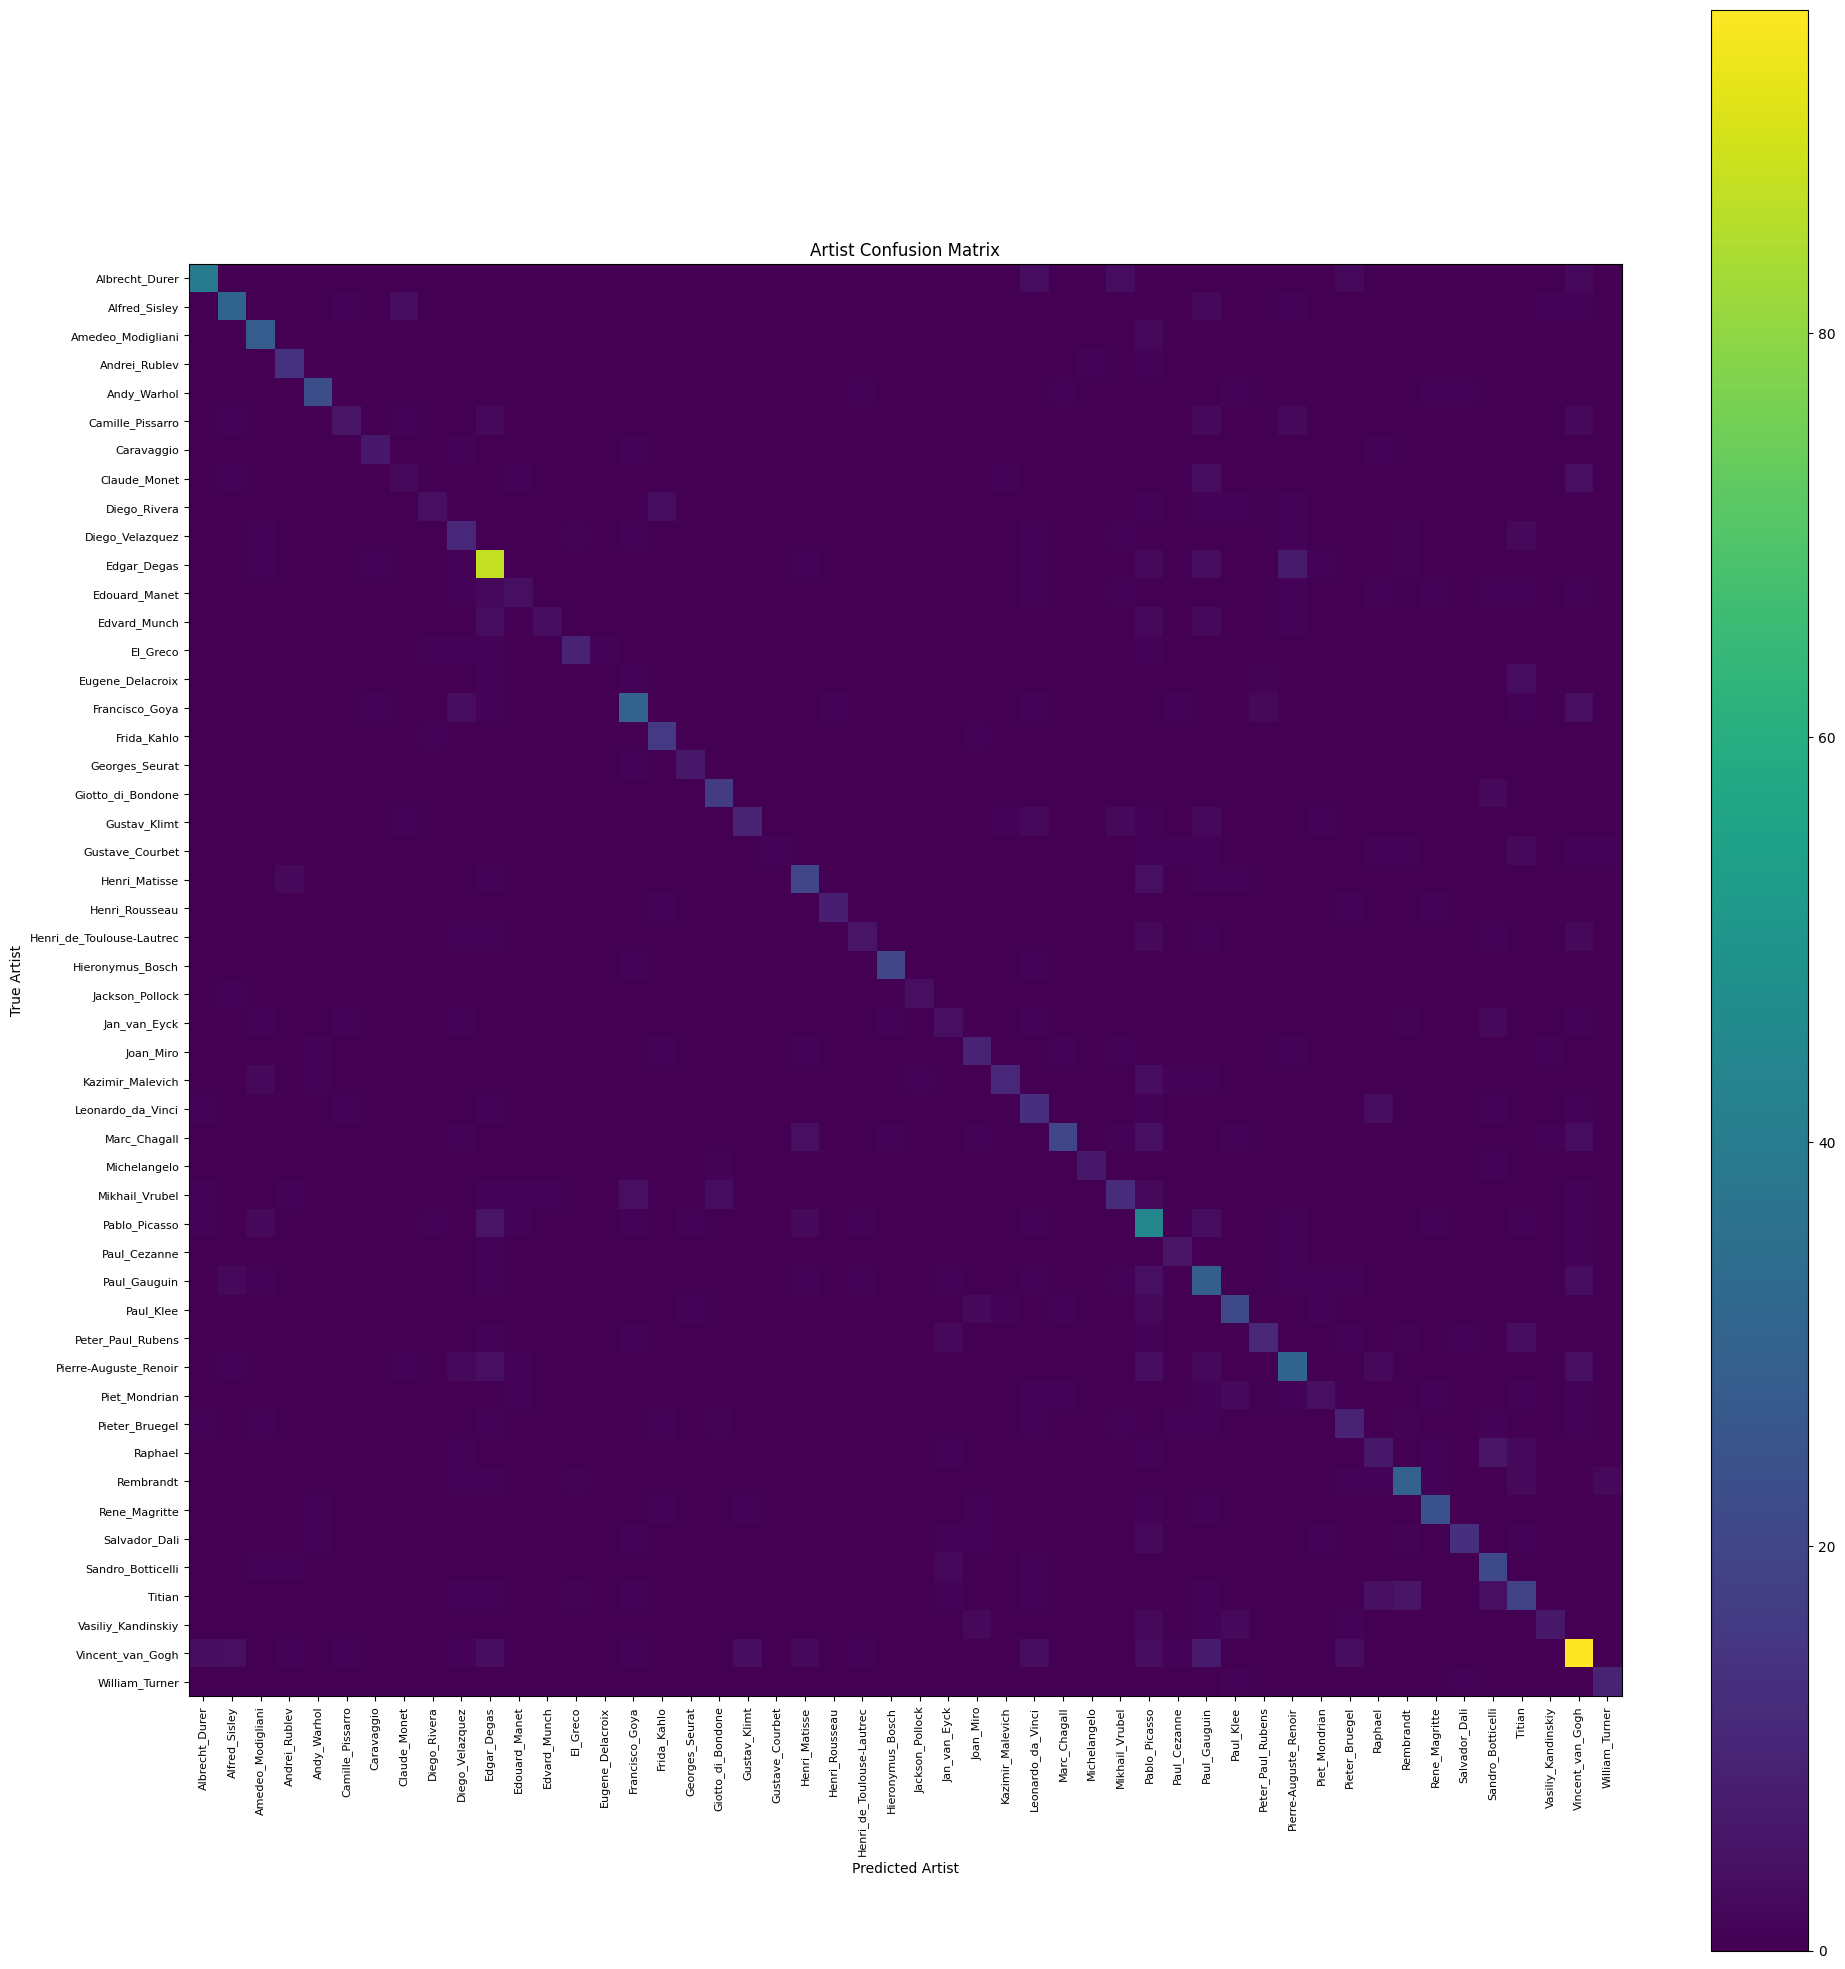

In [10]:
### 10. Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

# PLOT
plt.figure(figsize=(20, 20))

plt.imshow(cm, interpolation='nearest')
plt.title("Artist Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    rotation=90,
    fontsize=8
)

plt.yticks(
    tick_marks,
    class_names,
    fontsize=8
)

plt.xlabel("Predicted Artist")
plt.ylabel("True Artist")

plt.tight_layout()

plt.show()

## Confusion Matrix Interpretation

The confusion matrix reveals how the model distributes its predictions across the 50 artist classes.

A strong diagonal structure is clearly visible, indicating that the model correctly classifies a large portion of the artwork images.

Brighter values along the diagonal correspond to:
- high true-positive counts,
- stronger artist separability,
- and successful feature learning.

## Observed Classification Patterns

Several artist classes show particularly strong diagonal dominance, including:

- Edgar Degas
- Vincent van Gogh
- Pablo Picasso
- René Magritte
- Hieronymus Bosch

This suggests that the model learned highly distinctive visual representations for these artists.

## Artist Confusions

Off-diagonal activations reveal meaningful artist confusions rather than random prediction behavior.

Examples include:

- Vincent van Gogh ↔ Paul Gauguin
- Alfred Sisley ↔ Claude Monet
- Raphael ↔ Sandro Botticelli
- Titian ↔ Rembrandt
- Edgar Degas ↔ Pierre-Auguste Renoir

These confusions are historically and stylistically plausible because the involved artists often share:

- artistic movements,
- color composition,
- brushstroke techniques,
- portrait structures,
- or historical painting conventions.

## Model Behavior Analysis

The confusion matrix demonstrates that the model learned semantic stylistic relationships between artists instead of relying purely on memorization.

This behavior is particularly important in fine-grained artwork classification tasks, where:
- many classes exhibit subtle visual differences,
- artistic styles overlap historically,
- and visual ambiguity naturally exists between painters from similar movements.

## Overall Interpretation

The matrix confirms that:
- the model generalizes reasonably well,
- learned meaningful artistic feature representations,
- and captures stylistic similarities between painters in a coherent way.

Although some artist overlap remains challenging, the dominant diagonal pattern indicates successful multi-class artwork classification performance across the dataset.

# 11. Top Confusion Analysis

## Identifying Frequent Misclassifications

To better understand the model’s weaknesses and stylistic ambiguities, the most frequent off-diagonal confusion matrix entries are extracted and analyzed.

The diagonal values of the confusion matrix are removed so that only incorrect predictions remain visible.

The analysis then identifies the artist pairs with the highest number of misclassifications.

## Purpose of the Analysis

This step helps reveal:

- which artists are most visually similar according to the model,
- where the learned feature representations overlap,
- and which artistic styles remain difficult to separate.

The resulting confusion pairs provide deeper insight into:
- stylistic relationships between painters,
- limitations of the current model,
- and potential future improvement areas for fine-grained artwork classification.

In [11]:
### 11. Top Confusions Analysis

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

top_confusions = np.dstack(
    np.unravel_index(
        np.argsort(cm_no_diag.ravel())[::-1],
        cm_no_diag.shape
    )
)[0]

for true_idx, pred_idx in top_confusions[:20]:
    if cm_no_diag[true_idx, pred_idx] > 0:
        print(
            f"{class_names[true_idx]} predicted as {class_names[pred_idx]}: "
            f"{cm_no_diag[true_idx, pred_idx]} times"
        )

Vincent_van_Gogh predicted as Paul_Gauguin: 7 times
Edgar_Degas predicted as Pierre-Auguste_Renoir: 7 times
Pablo_Picasso predicted as Edgar_Degas: 5 times
Titian predicted as Rembrandt: 5 times
Raphael predicted as Sandro_Botticelli: 5 times
Marc_Chagall predicted as Pablo_Picasso: 4 times
Titian predicted as Sandro_Botticelli: 4 times
Titian predicted as Raphael: 4 times
Mikhail_Vrubel predicted as Francisco_Goya: 4 times
Francisco_Goya predicted as Vincent_van_Gogh: 4 times
Henri_Matisse predicted as Pablo_Picasso: 4 times
Vincent_van_Gogh predicted as Alfred_Sisley: 4 times
Marc_Chagall predicted as Henri_Matisse: 4 times
Pierre-Auguste_Renoir predicted as Vincent_van_Gogh: 4 times
Claude_Monet predicted as Vincent_van_Gogh: 4 times
Paul_Gauguin predicted as Pablo_Picasso: 4 times
Pierre-Auguste_Renoir predicted as Edgar_Degas: 4 times
Vincent_van_Gogh predicted as Leonardo_da_Vinci: 3 times
Albrecht_Durer predicted as Mikhail_Vrubel: 3 times
Vincent_van_Gogh predicted as Gustav_Kl

## Analysis of Frequent Artist Confusions

The extracted confusion pairs reveal that the model’s errors are generally meaningful and stylistically coherent rather than random.

Many of the most frequent misclassifications occur between artists who share:
- historical art movements,
- visual composition techniques,
- brushstroke patterns,
- or similar color palettes.

## Stylistically Meaningful Confusions

Several confusion pairs strongly align with known artistic similarities:

### Vincent van Gogh ↔ Paul Gauguin

This confusion is highly plausible because both artists belong to the Post-Impressionist movement and historically influenced one another directly.

The model likely detects similarities in:
- expressive brushstrokes,
- saturated colors,
- and compositional energy.

### Edgar Degas ↔ Pierre-Auguste Renoir

Both artists are associated with Impressionism and frequently depict:
- human subjects,
- soft lighting,
- and similar painterly textures.

### Raphael ↔ Sandro Botticelli

These Renaissance painters share:
- classical composition structures,
- anatomical proportions,
- and religious subject matter.

### Titian ↔ Rembrandt

Both artists often use:
- dramatic lighting,
- dark tonal contrast,
- and portrait-centered compositions.

### Claude Monet ↔ Vincent van Gogh

The model may confuse these artists due to:
- expressive color usage,
- textured brushwork,
- and landscape-focused compositions.

## Interpretation of Model Behavior

The confusion analysis suggests that the model learned higher-level stylistic relationships between artists rather than memorizing individual paintings.

This is an important indicator of meaningful representation learning.

Instead of producing random classification errors, the model tends to confuse artists with:
- overlapping artistic movements,
- related visual styles,
- or historically connected techniques.

## Remaining Challenges

Some confusions also highlight limitations of the current system:

- limited training data for several artists,
- stylistic diversity within an artist’s career,
- and overlap between fine-grained artistic features.

These challenges are common in artwork classification problems and reflect the inherent ambiguity of artistic style recognition.

# 12. Prediction Function

## Inference on Unseen Artwork Images

A custom prediction function is implemented to classify previously unseen paintings using the trained artist classification model.

The function performs the complete inference pipeline:

1. Load an input image
2. Resize the image to the required model input size
3. Convert the image into a TensorFlow-compatible array
4. Generate prediction probabilities using the trained model
5. Extract the Top-K highest-confidence artist predictions
6. Display the input artwork together with the predicted artist rankings

## Purpose of the Prediction Pipeline

This function allows the trained model to be used interactively on new artwork images outside the training dataset.

The prediction output includes:
- the most likely artist prediction,
- additional high-confidence candidate artists,
- and confidence percentages for each prediction.

Displaying the Top-5 predictions is particularly useful in fine-grained artwork classification tasks, where multiple artists may share visually similar styles.

In [12]:
### 12. Prediction Function

def predict_artist(image_path, model, class_names, top_k=5):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)[0]

    top_indices = np.argsort(preds)[::-1][:top_k]

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Top predictions:")
    for rank, idx in enumerate(top_indices, start=1):
        print(
            f"{rank}. {class_names[idx]} — {preds[idx] * 100:.2f}%"
        )

# 13. Grad-CAM Visualization

## Model Explainability and Visual Attention Analysis

To better understand how the neural network makes predictions, Grad-CAM (Gradient-weighted Class Activation Mapping) is implemented as a visualization technique.

Grad-CAM highlights the image regions that contribute most strongly to the model’s prediction.

The visualization overlays a heatmap onto the original artwork image, where:

- warmer colors indicate regions with stronger influence on the prediction,
- cooler colors indicate regions with lower importance.

## Purpose of Grad-CAM

This analysis helps determine whether the model focuses on meaningful artistic features such as:

- brushstroke patterns,
- facial structures,
- composition layout,
- object arrangement,
- or color distribution.

Grad-CAM can also reveal problematic behavior, including:
- shortcut learning,
- overreliance on signatures or watermarks,
- and attention to irrelevant background regions.

## Importance for Artwork Classification

In fine-grained artwork recognition tasks, explainability is especially important because many artist classes share visually similar characteristics.

Grad-CAM provides insight into:
- how the model differentiates artistic styles,
- what visual cues influence classification,
- and whether the learned representations are semantically meaningful.

In [14]:
### 13. Grad-CAM Visualization

def gradcam_for_image(image_path, model, class_names, last_conv_layer_name="top_conv"):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    base_model = model.get_layer("efficientnetb0")

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.imshow(
        heatmap,
        cmap="jet",
        alpha=0.4,
        extent=(0, 224, 224, 0)
    )
    plt.axis("off")
    plt.title(
        f"Predicted: {class_names[pred_index]} "
        f"({predictions[0][pred_index] * 100:.2f}%)"
    )
    plt.show()

# 14. Example Usage

## Running Predictions and Visual Explanations

The following example demonstrates how to:

1. Load the best saved model checkpoint
2. Predict the artist of an unseen artwork image
3. Generate a Grad-CAM visualization to analyze the model’s attention regions

## Workflow

- The saved model is restored from disk
- The prediction function outputs the Top-5 most likely artists
- Grad-CAM visualizes which image regions influenced the prediction

This allows the trained system to be used interactively for:
- artwork classification,
- qualitative analysis,
- and explainability demonstrations.

In [ ]:
### 14. Example Usage

model = tf.keras.models.load_model("artist_classifier_best.keras")
predict_artist("path/to/image.jpg", model, class_names)
gradcam_for_image("path/to/image.jpg", model, class_names)